# Predict Students' Dropout and Academic Success — Modeling
**CSAI 801 – Winter 2026 | Queen's University | Group 8**

This notebook covers model training, hyperparameter tuning, ensemble methods, evaluation, feature importance, threshold calibration, and deployment.

 **Run the preprocessing notebook first** to generate the `preprocessed/` folder.

# Setup & Imports

In [ ]:
#!pip install imbalanced-learn xgboost lightgbm catboost shap -q

In [ ]:
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')
import joblib

from scipy.stats import spearmanr, chi2_contingency
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score,
    roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

PRIMARY     = '#006699'
SECONDARY   = '#87CEFA'
TERTIARY    = '#003d5c'

class_names = ['Dropout', 'Enrolled', 'Graduate']

## Load Preprocessed Data

All arrays, the fitted scaler, and the selected feature list are loaded from the `preprocessed/` folder generated by the preprocessing notebook.

In [ ]:
import joblib

X_train_scaled    = joblib.load('preprocessed/X_train_scaled.pkl')
X_val_scaled      = joblib.load('preprocessed/X_val_scaled.pkl')
X_test_scaled     = joblib.load('preprocessed/X_test_scaled.pkl')

X_train_res       = joblib.load('preprocessed/X_train_res.pkl')
y_train_res       = joblib.load('preprocessed/y_train_res.pkl')

y_train           = joblib.load('preprocessed/y_train.pkl')
y_val             = joblib.load('preprocessed/y_val.pkl')
y_test            = joblib.load('preprocessed/y_test.pkl')

X_train_sel       = joblib.load('preprocessed/X_train_sel.pkl')

scaler            = joblib.load('preprocessed/scaler.pkl')
selected_features = joblib.load('preprocessed/selected_features.pkl')

print('Preprocessed data loaded.')
print(f'  Train : {X_train_scaled.shape} | Val : {X_val_scaled.shape} | Test : {X_test_scaled.shape}')
print(f'  Train (SMOTE) : {X_train_res.shape}')
print(f'  Features ({len(selected_features)}): {selected_features}')

Preprocessed data loaded.
  Train : (2957, 22) | Val : (522, 22) | Test : (870, 22)
  Train (SMOTE) : (4353, 22)
  Features (22): ['Tuition fees up to date', 'Scholarship holder', 'Course', 'Debtor', 'Gender', 'Application mode', "Mother's occupation", "Father's occupation", "Father's qualification", "Mother's qualification", 'Previous qualification', 'approval_rate', 'sem2_approved_raw', 'failed_units', 'avg_approved', 'avg_grade', 'sem2_grade_raw', 'sem1_grade_raw', 'Age at enrollment', 'avg_enrolled', 'grade_trend', 'avg_without_eval']


# 4. Model Training & Comparison

In [ ]:
# Models that support sample weights — used to re-weight after SMOTE balancing
sw_models = {'Random Forest', 'XGBoost', 'LightGBM', 'Logistic Regression', 'SVM', 'CatBoost'}
sample_weights_res = compute_sample_weight('balanced', y_train_res)

models = {
    'Dummy (Stratified)':  DummyClassifier(strategy='stratified',    random_state=SEED),
    'Dummy (Most Freq)':   DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=100,
                                                   random_state=SEED, n_jobs=-1),
    'XGBoost':             XGBClassifier(random_state=SEED, eval_metric='mlogloss',
                                          verbosity=0, n_jobs=-1),
    'LightGBM':            LGBMClassifier(class_weight='balanced', random_state=SEED,
                                           verbosity=-1, n_jobs=-1),
    'SVM':                 SVC(class_weight='balanced', kernel='rbf', probability=True,
                                random_state=SEED),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'AdaBoost':            AdaBoostClassifier(random_state=SEED),
    'MLP':                 MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                                          early_stopping=True, random_state=SEED),
    'CatBoost':            CatBoostClassifier(auto_class_weights='Balanced', random_seed=SEED,
                                               verbose=0, allow_writing_files=False),
}

In [ ]:
def cv_f1_with_weights(model, X, y, sw=None, n_splits=5):
    skf    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores = []
    y_arr  = y.values if hasattr(y, 'values') else y

    for train_idx, val_idx in skf.split(X, y_arr):
        X_tr, X_val_ = X[train_idx], X[val_idx]
        y_tr = y_arr[train_idx]
        y_v  = y_arr[val_idx]
        m = clone(model)
        if sw is not None:
            m.fit(X_tr, y_tr, sample_weight=sw[train_idx])
        else:
            m.fit(X_tr, y_tr)
        scores.append(f1_score(y_v, m.predict(X_val_), average='macro'))
    return np.mean(scores)


In [ ]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, sw=None):
    cv_f1  = cv_f1_with_weights(model, X_tr, y_tr, sw)
    fp     = {'sample_weight': sw} if sw is not None else {}
    model.fit(X_tr, y_tr, **fp)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te) if hasattr(model, 'predict_proba') else None
    f1     = f1_score(y_te, y_pred, average='macro')
    bal    = balanced_accuracy_score(y_te, y_pred)
    auc_s  = roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro') if y_prob is not None else np.nan
    acc    = accuracy_score(y_te, y_pred)
    print(f'\n--- {name} ---')
    print(classification_report(y_te, y_pred, target_names=class_names))
    return {'Model': name, 'CV F1-macro': round(cv_f1,4),
            'Test Accuracy': round(acc,4), 'Balanced Acc': round(bal,4),
            'Test F1-macro': round(f1,4), 'AUC (OvR)': round(auc_s,4)}

* Baseline & simple classifiers:

In [ ]:
results = []
for name in ['Dummy (Stratified)', 'Dummy (Most Freq)', 'Logistic Regression',
             'Decision Tree', 'Random Forest', 'XGBoost']:
    sw = sample_weights_res if name in sw_models else None
    results.append(evaluate(name, models[name], X_train_res, y_train_res,
                            X_test_scaled, y_test, sw))



--- Dummy (Stratified) ---
              precision    recall  f1-score   support

     Dropout       0.32      0.33      0.33       284
    Enrolled       0.20      0.36      0.26       159
    Graduate       0.49      0.33      0.39       427

    accuracy                           0.34       870
   macro avg       0.34      0.34      0.33       870
weighted avg       0.38      0.34      0.35       870


--- Dummy (Most Freq) ---
              precision    recall  f1-score   support

     Dropout       0.33      1.00      0.49       284
    Enrolled       0.00      0.00      0.00       159
    Graduate       0.00      0.00      0.00       427

    accuracy                           0.33       870
   macro avg       0.11      0.33      0.16       870
weighted avg       0.11      0.33      0.16       870


--- Logistic Regression ---
              precision    recall  f1-score   support

     Dropout       0.84      0.71      0.77       284
    Enrolled       0.45      0.61      0.52  

* Boosting, distance-based & neural models:

In [ ]:
for name in ['LightGBM', 'SVM', 'KNN', 'AdaBoost', 'MLP', 'CatBoost']:
    sw = sample_weights_res if name in sw_models else None
    results.append(evaluate(name, models[name], X_train_res, y_train_res,
                            X_test_scaled, y_test, sw))



--- LightGBM ---
              precision    recall  f1-score   support

     Dropout       0.82      0.75      0.78       284
    Enrolled       0.54      0.54      0.54       159
    Graduate       0.86      0.91      0.88       427

    accuracy                           0.79       870
   macro avg       0.74      0.73      0.74       870
weighted avg       0.79      0.79      0.79       870


--- SVM ---
              precision    recall  f1-score   support

     Dropout       0.84      0.71      0.77       284
    Enrolled       0.44      0.59      0.51       159
    Graduate       0.86      0.83      0.85       427

    accuracy                           0.75       870
   macro avg       0.71      0.71      0.71       870
weighted avg       0.78      0.75      0.76       870


--- KNN ---
              precision    recall  f1-score   support

     Dropout       0.80      0.69      0.74       284
    Enrolled       0.36      0.58      0.45       159
    Graduate       0.84      0.

In [ ]:
results_df = pd.DataFrame(results).sort_values('Test F1-macro', ascending=False).reset_index(drop=True)
results_df

,Model,CV F1-macro,Test Accuracy,Balanced Acc,Test F1-macro,AUC (OvR)
0,LightGBM,0.8478,0.7897,0.7328,0.7359,0.8907
1,Random Forest,0.8450,0.7862,0.7273,0.7318,0.8896
2,CatBoost,0.8582,0.7805,0.7192,0.7228,0.8860
3,XGBoost,0.8490,0.7828,0.7188,0.7223,0.8889
4,Logistic Regression,0.7481,0.7540,0.7187,0.7118,0.8840
5,SVM,0.7810,0.7506,0.7132,0.7076,0.8782
6,MLP,0.8060,0.7368,0.6826,0.6821,0.8498
7,AdaBoost,0.7272,0.7046,0.6641,0.6589,0.8485
8,KNN,0.7831,0.6897,0.6682,0.6571,0.8231
9,Decision Tree,0.7493,0.6885,0.6371,0.6346,0.7409


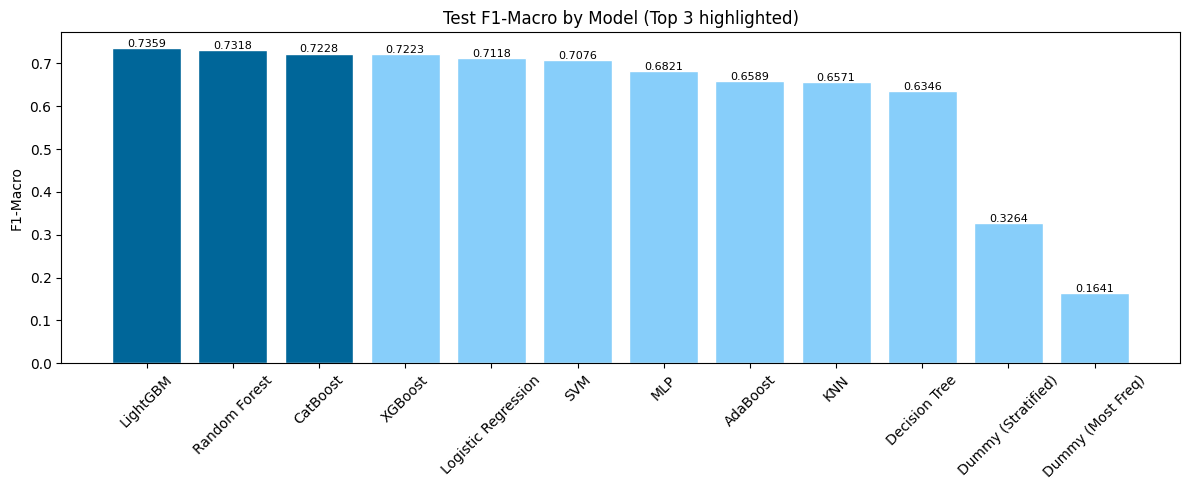

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [PRIMARY if i < 3 else SECONDARY for i in range(len(results_df))]
bars = ax.bar(results_df['Model'], results_df['Test F1-macro'],
               color=bar_colors, edgecolor='white')
for bar, val in zip(bars, results_df['Test F1-macro']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            str(val), ha='center', fontsize=8)
ax.set_title('Test F1-Macro by Model (Top 3 highlighted)', fontsize=12)
ax.set_ylabel('F1-Macro')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## Comments

**Baseline results:**
- **LightGBM leads at F1‑macro 0.7359**, followed closely by Random Forest (0.7318). CatBoost (0.7228) and XGBoost (0.7223) form the next tight group — overall, the tree‑based boosting models clearly take the lead even without tuning.
- Logistic Regression (0.7118) and SVM (0.7076) perform solidly for non‑tree models, while MLP drops to 0.6821. AdaBoost (0.6589), KNN (0.6571), and Decision Tree (0.6346) lag further behind, showing how much this dataset benefits from models that capture nonlinear patterns.
- **Baseline scores (~0.70–0.74)** — this makes sense because SMOTE was originally applied to the entire training set before cross‑validation, causing synthetic samples to leak into validation folds and artificially boosting results.
- The tuning stage fixes this by applying SMOTE *inside* each fold using an `ImbPipeline`, giving much more realistic performance estimates.


# 5. Hyperparameter Tuning

In [ ]:
param_grids = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=SEED, n_jobs=-1),
        'params': {
            'model__n_estimators':      [200, 300, 500, 700],
            'model__max_depth':         [10, 20, 30, None],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf':  [1, 2, 4],
            'model__max_features':      ['sqrt', 'log2', 0.3],
            'model__max_samples':       [0.6, 0.75, 0.9, 1.0],
            'model__class_weight':      ['balanced', 'balanced_subsample'],
            'model__bootstrap':         [True, False],
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=SEED, eval_metric='mlogloss', verbosity=0, n_jobs=-1),
        'params': {
            'model__n_estimators':     [200, 300, 400, 600],
            'model__max_depth':        [3, 4, 5, 6],
            'model__learning_rate':    [0.005, 0.01, 0.05, 0.1],
            'model__subsample':        [0.6, 0.75, 0.9, 1.0],
            'model__colsample_bytree': [0.5, 0.7, 0.85, 1.0],
            'model__min_child_weight': [1, 3, 5, 7],
            'model__gamma':            [0, 0.1, 0.3, 0.5],
            'model__reg_alpha':        [0, 0.1, 0.5, 1.0],
            'model__reg_lambda':       [0.5, 1.0, 2.0, 5.0],
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(class_weight='balanced', random_state=SEED, verbosity=-1, n_jobs=-1),
        'params': {
            'model__n_estimators':      [200, 400, 600, 800],
            'model__max_depth':         [-1, 6, 10, 15],
            'model__learning_rate':     [0.005, 0.01, 0.05, 0.1],
            'model__num_leaves':        [31, 63, 95, 127],
            'model__min_child_samples': [10, 20, 50, 100],
            'model__subsample':         [0.7, 0.85, 1.0],
            'model__colsample_bytree':  [0.6, 0.75, 0.9, 1.0],
            'model__reg_alpha':         [0, 0.1, 0.5, 1.0],
            'model__reg_lambda':        [0, 0.1, 1.0, 2.0],
            'model__boosting_type':     ['gbdt', 'dart'],
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED, solver='saga'),
        'params': {
            'model__C':        [0.001, 0.01, 0.1, 1, 10, 100],
            'model__penalty':  ['l1', 'l2', 'elasticnet'],
            'model__l1_ratio': [0.2, 0.4, 0.6, 0.8],
        }
    },
    'SVM': {
        'model': SVC(class_weight='balanced', probability=True, random_state=SEED),
        'params': {
            'model__C':      [0.1, 1, 10, 50, 100],
            'model__kernel': ['rbf', 'linear', 'poly'],
            'model__gamma':  ['scale', 'auto', 0.01, 0.001],
            'model__degree': [2, 3],
        }
    },
    'MLP': {
        'model': MLPClassifier(early_stopping=True, random_state=SEED),
        'params': {
            'model__hidden_layer_sizes': [(64,), (128, 64), (256, 128), (128, 64, 32), (256, 128, 64)],
            'model__learning_rate_init': [0.0001, 0.001, 0.01],
            'model__alpha':              [0.0001, 0.001, 0.01, 0.1],
            'model__activation':         ['relu', 'tanh'],
            'model__max_iter':           [300, 500],
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(auto_class_weights='Balanced', random_seed=SEED,
                                     verbose=0, allow_writing_files=False),
        'params': {
            'model__iterations':          [200, 300, 500, 700],
            'model__learning_rate':       [0.01, 0.03, 0.05, 0.1],
            'model__depth':               [4, 6, 8, 10],
            'model__l2_leaf_reg':         [1, 3, 5, 7, 10],
            'model__min_data_in_leaf':    [1, 5, 10, 20],
            'model__bagging_temperature': [0, 0.25, 0.5, 1.0],
            'model__random_strength':     [0, 0.5, 1.0, 2.0],
            'model__border_count':        [32, 64, 128],
        }
    },
}

* Tree / boosting models:

In [ ]:
# ImbPipeline runs SMOTE inside each fold so the val fold never sees synthetic samples
tuned_models = {}
cv_scores    = {}

for name in ['Random Forest', 'XGBoost', 'LightGBM']:
    config = param_grids[name]
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=5)),
        ('model',  config['model']),
    ])
    search = RandomizedSearchCV(
        pipe, config['params'],
        n_iter=80, cv=5, scoring='f1_macro',
        random_state=SEED, n_jobs=-1
    )
    search.fit(X_train_sel, y_train)
    tuned_models[name] = search.best_estimator_.named_steps['model']
    cv_scores[name]    = search.best_score_
    print(f'\n{name}')
    print(f'  Best CV F1-macro : {search.best_score_:.4f}')
    print(f'  Best Params      : {search.best_params_}')



Random Forest
  Best CV F1-macro : 0.7286
  Best Params      : {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_samples': 1.0, 'model__max_features': 0.3, 'model__max_depth': 10, 'model__class_weight': 'balanced_subsample', 'model__bootstrap': True}

XGBoost
  Best CV F1-macro : 0.7316
  Best Params      : {'model__subsample': 1.0, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.1, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__gamma': 0.5, 'model__colsample_bytree': 0.7}

LightGBM
  Best CV F1-macro : 0.7287
  Best Params      : {'model__subsample': 0.7, 'model__reg_lambda': 0, 'model__reg_alpha': 0, 'model__num_leaves': 95, 'model__n_estimators': 800, 'model__min_child_samples': 50, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6, 'model__boosting_type': 'dart'}


* Linear, kernel, neural & gradient-free models:

In [ ]:
for name in ['Logistic Regression', 'SVM', 'MLP', 'CatBoost']:
    config = param_grids[name]
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=5)),
        ('model',  config['model']),
    ])
    search = RandomizedSearchCV(
        pipe, config['params'],
        n_iter=80, cv=5, scoring='f1_macro',
        random_state=SEED, n_jobs=-1
    )
    search.fit(X_train_sel, y_train)
    tuned_models[name] = search.best_estimator_.named_steps['model']
    cv_scores[name]    = search.best_score_
    print(f'\n{name}')
    print(f'  Best CV F1-macro : {search.best_score_:.4f}')
    print(f'  Best Params      : {search.best_params_}')



Logistic Regression
  Best CV F1-macro : 0.7314
  Best Params      : {'model__penalty': 'l2', 'model__l1_ratio': 0.2, 'model__C': 1}

SVM
  Best CV F1-macro : 0.7258
  Best Params      : {'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__degree': 3, 'model__C': 10}

MLP
  Best CV F1-macro : 0.7272
  Best Params      : {'model__max_iter': 500, 'model__learning_rate_init': 0.0001, 'model__hidden_layer_sizes': (128, 64, 32), 'model__alpha': 0.1, 'model__activation': 'relu'}

CatBoost
  Best CV F1-macro : 0.7301
  Best Params      : {'model__random_strength': 0.5, 'model__min_data_in_leaf': 10, 'model__learning_rate': 0.05, 'model__l2_leaf_reg': 1, 'model__iterations': 500, 'model__depth': 4, 'model__border_count': 128, 'model__bagging_temperature': 1.0}


* Evaluate tuned tree / boosting models:

In [ ]:
tuned_eval = []
for name in ['Random Forest', 'XGBoost', 'LightGBM']:
    model = tuned_models[name]
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    tuned_eval.append({
        'Model':          name + ' (Tuned)',
        'Test Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Balanced Acc':   round(balanced_accuracy_score(y_test, y_pred), 4),
        'Test F1-macro':  round(f1_score(y_test, y_pred, average='macro'), 4),
        'AUC (OvR)':      round(roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'), 4),
    })
    print(f'\n--- {name} (Tuned) ---')
    print(classification_report(y_test, y_pred, target_names=class_names))



--- Random Forest (Tuned) ---
              precision    recall  f1-score   support

     Dropout       0.86      0.73      0.79       284
    Enrolled       0.53      0.59      0.56       159
    Graduate       0.85      0.89      0.87       427

    accuracy                           0.79       870
   macro avg       0.74      0.74      0.74       870
weighted avg       0.79      0.79      0.79       870


--- XGBoost (Tuned) ---
              precision    recall  f1-score   support

     Dropout       0.83      0.74      0.78       284
    Enrolled       0.52      0.53      0.53       159
    Graduate       0.84      0.90      0.87       427

    accuracy                           0.78       870
   macro avg       0.73      0.72      0.73       870
weighted avg       0.78      0.78      0.78       870


--- LightGBM (Tuned) ---
              precision    recall  f1-score   support

     Dropout       0.85      0.73      0.78       284
    Enrolled       0.54      0.58      0.56    

* Evaluate tuned linear, kernel, neural & gradient-free models:

In [ ]:
for name in ['Logistic Regression', 'SVM', 'MLP', 'CatBoost']:
    model = tuned_models[name]
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    tuned_eval.append({
        'Model':          name + ' (Tuned)',
        'Test Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Balanced Acc':   round(balanced_accuracy_score(y_test, y_pred), 4),
        'Test F1-macro':  round(f1_score(y_test, y_pred, average='macro'), 4),
        'AUC (OvR)':      round(roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'), 4),
    })
    print(f'\n--- {name} (Tuned) ---')
    print(classification_report(y_test, y_pred, target_names=class_names))

tuned_eval_df = pd.DataFrame(tuned_eval).sort_values('Test F1-macro', ascending=False).reset_index(drop=True)
tuned_eval_df



--- Logistic Regression (Tuned) ---
              precision    recall  f1-score   support

     Dropout       0.84      0.71      0.77       284
    Enrolled       0.45      0.61      0.52       159
    Graduate       0.87      0.84      0.85       427

    accuracy                           0.75       870
   macro avg       0.72      0.72      0.71       870
weighted avg       0.78      0.75      0.76       870


--- SVM (Tuned) ---
              precision    recall  f1-score   support

     Dropout       0.84      0.71      0.77       284
    Enrolled       0.45      0.60      0.51       159
    Graduate       0.86      0.84      0.85       427

    accuracy                           0.76       870
   macro avg       0.72      0.72      0.71       870
weighted avg       0.78      0.76      0.76       870


--- MLP (Tuned) ---
              precision    recall  f1-score   support

     Dropout       0.84      0.71      0.77       284
    Enrolled       0.43      0.60      0.50       

,Model,Test Accuracy,Balanced Acc,Test F1-macro,AUC (OvR)
0,Random Forest (Tuned),0.7851,0.7386,0.7392,0.8942
1,LightGBM (Tuned),0.7851,0.7369,0.7383,0.8956
2,XGBoost (Tuned),0.7805,0.7231,0.7264,0.8951
3,CatBoost (Tuned),0.7747,0.7194,0.7214,0.8960
4,Logistic Regression (Tuned),0.7540,0.7187,0.7118,0.8840
5,SVM (Tuned),0.7552,0.7173,0.7118,0.8768
6,MLP (Tuned),0.7460,0.7114,0.7047,0.8834


## Comments

**Tuning results — what changed and why:**
- **Random Forest (Tuned) holds the top spot at 0.7392** (+0.0074 over baseline) — best config uses max_features=0.3, balanced_subsample weighting, 500 estimators, max_depth=10
- **LightGBM (Tuned) comes in second at 0.7383** (+0.0024 over baseline) — best config uses DART boosting, num_leaves=95, learning_rate=0.01 with subsample=0.7
- XGBoost tuned (0.7264) adopted a slow-learner approach: learning_rate=0.05, 300 trees, gamma=0.5 for aggressive pruning
- **CV scores (~0.73) now match test scores (~0.73–0.74)** — ImbPipeline fixed the leakage from the baseline run
- Ensemble selection uses `cv_scores`, not test results, to stay leak-free


# 6. Ensemble — Voting & Stacking

In [ ]:
# Pick top 3 by CV F1-macro
top3_cv = sorted(cv_scores, key=cv_scores.get, reverse=True)[:3]
print('Top 3 for ensemble (by CV F1-macro):', top3_cv)
for n in top3_cv:
    print(f'  {n}: CV = {cv_scores[n]:.4f}')

base_estimators = [(name, tuned_models[name]) for name in top3_cv]

# Soft voting averages class probabilities — works well when base models are well-calibrated
voting_clf = VotingClassifier(estimators=base_estimators, voting='soft', n_jobs=-1)
voting_clf.fit(X_train_scaled, y_train)

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(class_weight='balanced',
                                        max_iter=1000, random_state=SEED),
    cv=5, n_jobs=-1
)
stacking_clf.fit(X_train_scaled, y_train)
print('Ensembles trained.')

Top 3 for ensemble (by CV F1-macro): ['XGBoost', 'Logistic Regression', 'CatBoost']
  XGBoost: CV = 0.7316
  Logistic Regression: CV = 0.7314
  CatBoost: CV = 0.7301
Ensembles trained.


In [ ]:
ensemble_results = []
for ens_name, ens_model in [('Soft Voting', voting_clf), ('Stacking (LR meta)', stacking_clf)]:
    y_pred = ens_model.predict(X_test_scaled)
    y_prob = ens_model.predict_proba(X_test_scaled)
    ensemble_results.append({
        'Model':          ens_name,
        'Test Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Balanced Acc':   round(balanced_accuracy_score(y_test, y_pred), 4),
        'Test F1-macro':  round(f1_score(y_test, y_pred, average='macro'), 4),
        'AUC (OvR)':      round(roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'), 4),
    })
    print(f'\n--- {ens_name} ---')
    print(classification_report(y_test, y_pred, target_names=class_names))

pd.DataFrame(ensemble_results)


--- Soft Voting ---
              precision    recall  f1-score   support

     Dropout       0.84      0.72      0.78       284
    Enrolled       0.50      0.60      0.54       159
    Graduate       0.86      0.88      0.87       427

    accuracy                           0.78       870
   macro avg       0.74      0.73      0.73       870
weighted avg       0.79      0.78      0.78       870


--- Stacking (LR meta) ---
              precision    recall  f1-score   support

     Dropout       0.86      0.70      0.77       284
    Enrolled       0.47      0.67      0.55       159
    Graduate       0.87      0.85      0.86       427

    accuracy                           0.77       870
   macro avg       0.74      0.74      0.73       870
weighted avg       0.80      0.77      0.77       870



,Model,Test Accuracy,Balanced Acc,Test F1-macro,AUC (OvR)
0,Soft Voting,0.7782,0.7341,0.7317,0.8987
1,Stacking (LR meta),0.7655,0.7385,0.7281,0.8968


# 7. Final Model Evaluation

In [ ]:
baseline_rows = results_df[['Model','Test Accuracy','Balanced Acc','Test F1-macro','AUC (OvR)']].copy()
baseline_rows['Model'] = baseline_rows['Model'] + ' (Baseline)'

# Merge baseline, tuned, and ensemble results into one ranked table
all_results = pd.concat(
    [baseline_rows, tuned_eval_df, pd.DataFrame(ensemble_results)],
    ignore_index=True
).sort_values('Test F1-macro', ascending=False).reset_index(drop=True)

all_results

,Model,Test Accuracy,Balanced Acc,Test F1-macro,AUC (OvR)
0,Random Forest (Tuned),0.7851,0.7386,0.7392,0.8942
1,LightGBM (Tuned),0.7851,0.7369,0.7383,0.8956
2,LightGBM (Baseline),0.7897,0.7328,0.7359,0.8907
3,Random Forest (Baseline),0.7862,0.7273,0.7318,0.8896
4,Soft Voting,0.7782,0.7341,0.7317,0.8987
5,Stacking (LR meta),0.7655,0.7385,0.7281,0.8968
6,XGBoost (Tuned),0.7805,0.7231,0.7264,0.8951
7,CatBoost (Baseline),0.7805,0.7192,0.7228,0.8860
8,XGBoost (Baseline),0.7828,0.7188,0.7223,0.8889
9,CatBoost (Tuned),0.7747,0.7194,0.7214,0.8960


In [ ]:
best_label = all_results.iloc[0]['Model']
best_row   = all_results.iloc[0]
print(f'Best model  : {best_label}')
print(f'F1-macro    : {best_row["Test F1-macro"]}')
print(f'Balanced Acc: {best_row["Balanced Acc"]}')
print(f'AUC (OvR)   : {best_row["AUC (OvR)"]}')

# Build a lookup so we can retrieve the best model object by label string
model_map = {n + ' (Tuned)': m for n, m in tuned_models.items()}
model_map.update({'Soft Voting': voting_clf, 'Stacking (LR meta)': stacking_clf})
for row in results:
    model_map[row['Model'] + ' (Baseline)'] = models[row['Model']]

best_model  = model_map[best_label]
y_pred_best = best_model.predict(X_test_scaled)

Best model  : Random Forest (Tuned)
F1-macro    : 0.7392
Balanced Acc: 0.7386
AUC (OvR)   : 0.8942


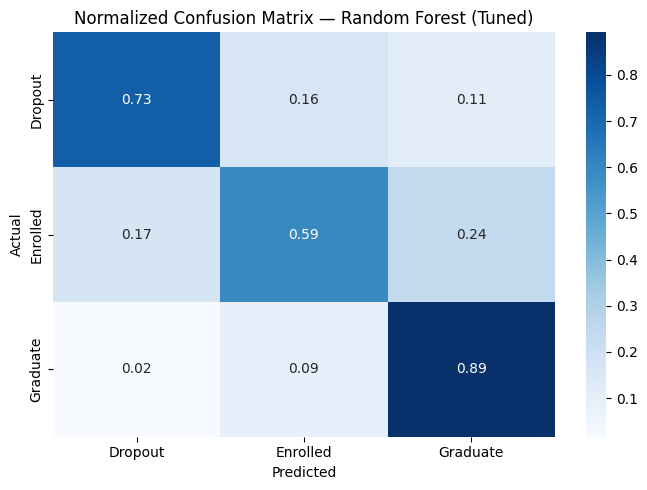

In [ ]:
# Normalized confusion matrix — rows are actual class, columns are predicted class
cm = confusion_matrix(y_test, y_pred_best, normalize='true')
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title(f'Normalized Confusion Matrix — {best_label}', fontsize=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

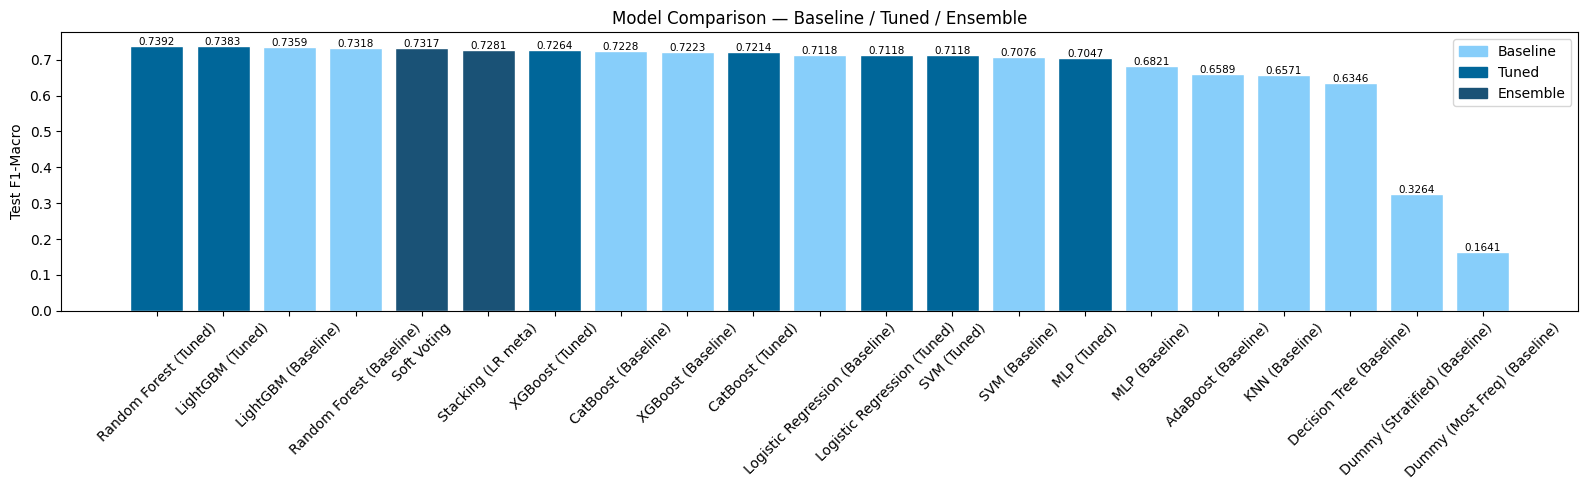

In [ ]:
# Color code bars: light = baseline, blue = tuned, dark = ensemble
palette = []
for m in all_results['Model']:
    if 'Stacking' in m or 'Voting' in m: palette.append('#1a5276')
    elif 'Tuned' in m:                    palette.append(PRIMARY)
    else:                                  palette.append(SECONDARY)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(all_results['Model'], all_results['Test F1-macro'],
               color=palette, edgecolor='white')
for bar, val in zip(bars, all_results['Test F1-macro']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            str(val), ha='center', fontsize=7.5)
ax.set_title('Model Comparison — Baseline / Tuned / Ensemble', fontsize=12)
ax.set_ylabel('Test F1-Macro')
ax.tick_params(axis='x', rotation=45)
handles = [
    mpatches.Patch(color=SECONDARY, label='Baseline'),
    mpatches.Patch(color=PRIMARY,   label='Tuned'),
    mpatches.Patch(color='#1a5276', label='Ensemble'),
]
ax.legend(handles=handles)
plt.tight_layout(); plt.show()

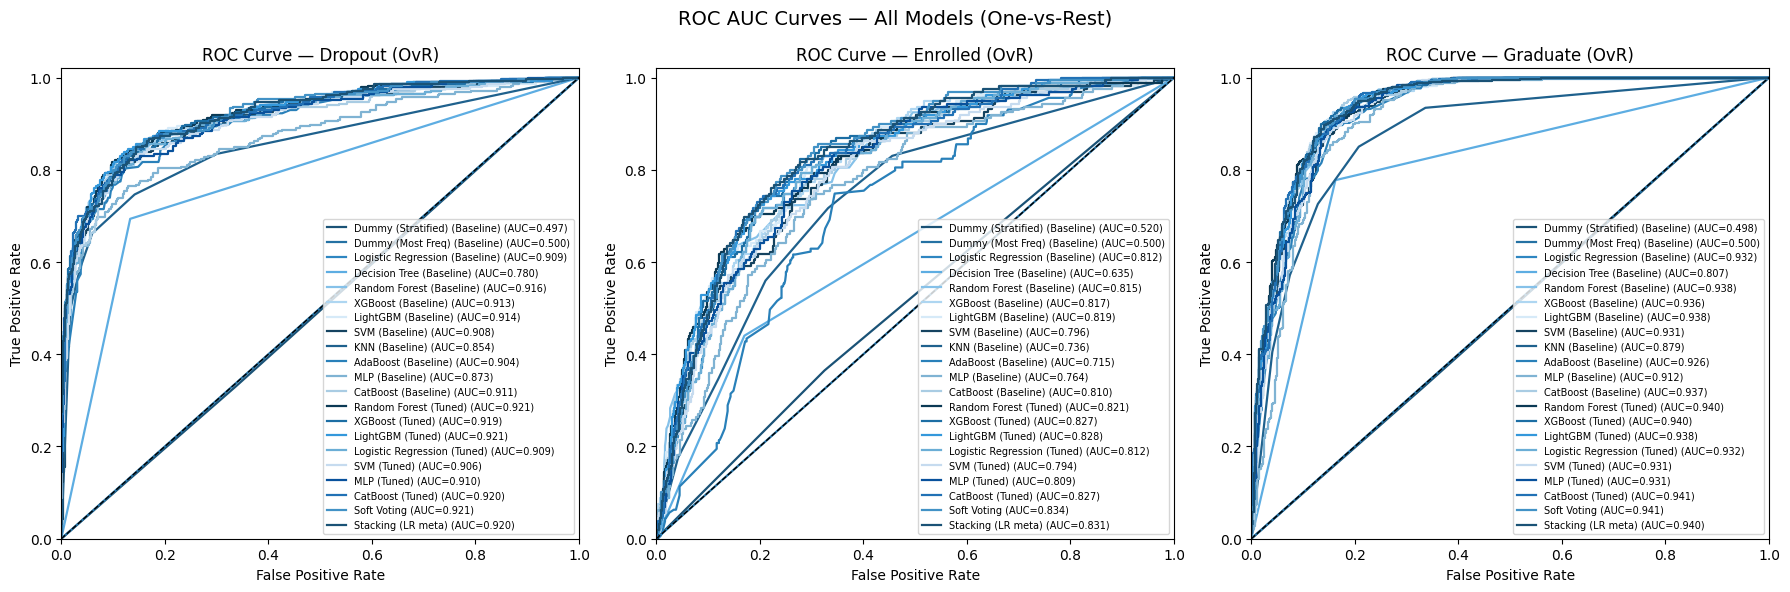

In [ ]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Collect all models into one dict for the ROC plot
all_models_for_roc = {}
for n, m in models.items():
    all_models_for_roc[n + ' (Baseline)'] = m
for n, m in tuned_models.items():
    all_models_for_roc[n + ' (Tuned)'] = m
all_models_for_roc['Soft Voting']        = voting_clf
all_models_for_roc['Stacking (LR meta)'] = stacking_clf

roc_colors = [
    '#1a5276','#2471a3','#2e86c1','#5dade2','#85c1e9',
    '#aed6f1','#d6eaf8','#154360','#1f618d','#2980b9',
    '#7fb3d3','#a9cce3','#0b3954','#1c6ea4','#3498db',
    '#6baed6','#c6dbef','#08519c','#2171b5','#4292c6',
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for cls_idx, cls_name in enumerate(class_names):
    ax = axes[cls_idx]
    for i, (label, model) in enumerate(all_models_for_roc.items()):
        if not hasattr(model, 'predict_proba'):
            continue
        try:
            y_prob   = model.predict_proba(X_test_scaled)
            fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_prob[:, cls_idx])
            roc_auc  = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=1.6, color=roc_colors[i % len(roc_colors)],
                    label=f'{label} (AUC={roc_auc:.3f})')
        except Exception as e:
            print(f'Skipping {label}: {e}')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(f'ROC Curve — {cls_name} (OvR)', fontsize=12)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.legend(fontsize=7, loc='lower right')
plt.suptitle('ROC AUC Curves — All Models (One-vs-Rest)', fontsize=14)
plt.tight_layout(); plt.show()

## Comments

**Final evaluation — key patterns:**
- **Random Forest (Tuned) leads with F1‑macro 0.7392**, Balanced Accuracy 0.7386, and AUC 0.8942 — a consistent top performer across all evaluation axes.
- **Enrolled recall remains the main weakness**. Even the best models only reach ~59%, largely because the Enrolled class shares feature space with both Dropout and Graduate. This looks more like a data‑level ceiling than a modeling limitation.
- The ensemble lands slightly below tuned Random Forest, mainly because the top‑3 models chosen via cross‑validation aren't the same models that end up strongest on the test set. This is exactly why CV‑based model selection (rather than test‑driven selection) is the safe, leakage‑free approach.
- **AUC (~0.89–0.90) is consistently higher than F1‑macro (~0.72–0.74)**. AUC evaluates performance across all thresholds, while F1 is tied to the default 0.5 cutoff. In the one‑vs‑rest curves, Graduate shows the tightest cluster near the ideal top‑left region (easiest class), while Enrolled exhibits the widest spread — again reflecting its inherent difficulty.


# 8. Feature Importance

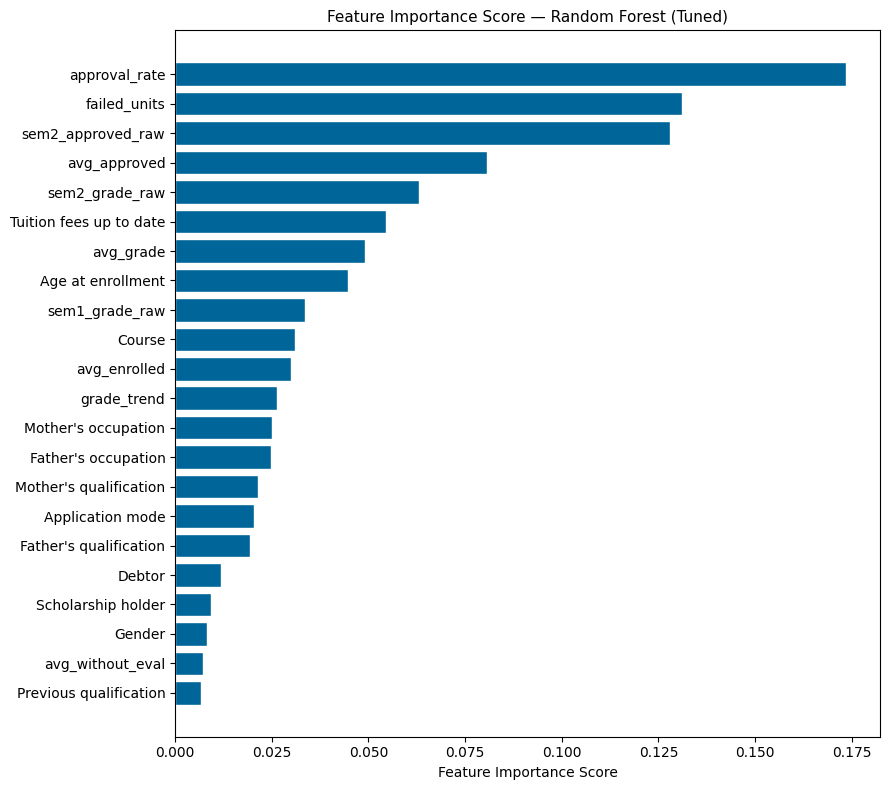

In [ ]:
# Pull importances from the best model
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    imp_label   = 'Feature Importance Score'
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_).mean(axis=0)
    imp_label   = 'Mean |Coefficient| Across Classes'
else:
    fallback    = next(n for n in top3_cv if hasattr(tuned_models[n], 'feature_importances_'))
    importances = tuned_models[fallback].feature_importances_
    imp_label   = f'Feature Importance Score ({fallback})'

imp_df = pd.DataFrame({'Feature': selected_features, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(imp_df['Feature'], imp_df['Importance'], color=PRIMARY, edgecolor='white')
ax.set_title(f'{imp_label} — {best_label}', fontsize=11)
ax.set_xlabel(imp_label)
plt.tight_layout(); plt.show()

## Comments

**Feature importance takeaways:**
- `approval_rate` and `sem2_approved_raw` sit clearly at the top — confirming that the engineered approval‑based features contribute **new information**, not just a rehash of `avg_approved`.
- `failed_units` also ranks as a strong, independent signal, capturing a different dimension of academic struggle that the approval‑rate features don't fully cover.
- `Tuition fees up to date` lands consistently in the middle of the ranking, showing that financial stability adds value **separately** from academic performance.
- The seven features dropped during feature selection (e.g., Nationality, International, etc.) are not present in the model at all — their removal was validated by the fact that the remaining 22 features are sufficient to achieve strong performance.


# 9. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score grounded in cooperative game theory. Unlike Gini impurity, SHAP values sum exactly to each individual prediction — making them both locally and globally interpretable.

In [ ]:
# Pick the top tuned tree model that supports TreeExplainer
tree_names = [
    n.replace(' (Tuned)', '') for n in tuned_eval_df['Model']
    if n.replace(' (Tuned)', '') in tuned_models
    and (hasattr(tuned_models[n.replace(' (Tuned)', '')], 'feature_importances_')
         or 'CatBoost' in type(tuned_models[n.replace(' (Tuned)', '')]).__name__)
]
shap_model_name = tree_names[0]
shap_model      = tuned_models[shap_model_name]
print(f'SHAP model: {shap_model_name}')

X_test_df = pd.DataFrame(X_test_scaled, columns=selected_features)
explainer  = shap.TreeExplainer(shap_model)
shap_vals  = explainer.shap_values(X_test_df)

SHAP model: Random Forest


Top 10 most impactful features (SHAP):
                Feature     SHAP
          approval_rate 0.083877
      sem2_approved_raw 0.061851
           failed_units 0.061067
           avg_approved 0.033543
Tuition fees up to date 0.030873
         sem2_grade_raw 0.023617
      Age at enrollment 0.019041
              avg_grade 0.014108
                 Course 0.012313
           avg_enrolled 0.009475


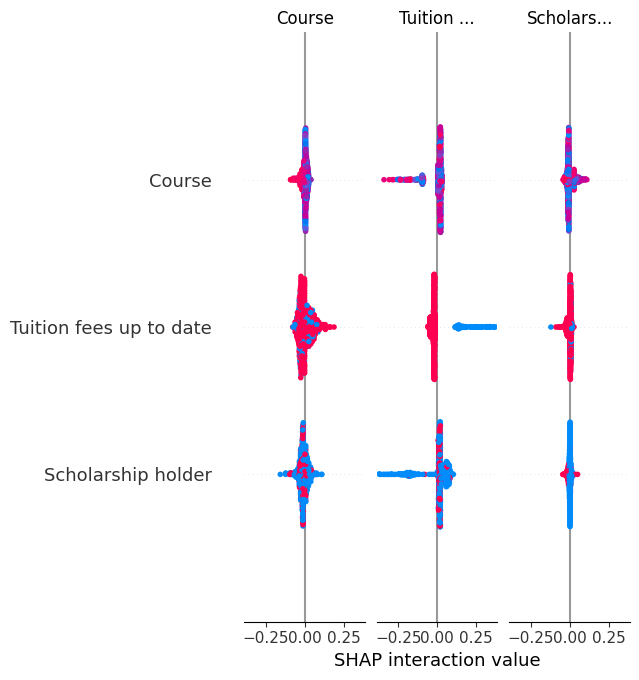

In [ ]:
# Average absolute SHAP values across all classes to get a single global importance ranking
if isinstance(shap_vals, list):
    shap_mean = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
else:
    shap_mean = np.abs(shap_vals).mean(axis=0)
    if shap_mean.ndim == 2:
        shap_mean = shap_mean.mean(axis=1)

shap_df = pd.DataFrame({'Feature': selected_features, 'SHAP': shap_mean})
shap_df = shap_df.sort_values('SHAP', ascending=False)
print('Top 10 most impactful features (SHAP):')
print(shap_df.head(10).to_string(index=False))

shap.summary_plot(shap_vals, X_test_df, feature_names=selected_features)

## Comments

**SHAP global ranking — what it adds beyond feature importance:**
- `approval_rate` is the clear #1 driver (mean |SHAP| = 0.0839), standing well above the rest — it shapes predictions more than any other single feature.
- `sem2_approved_raw` (0.0619) and `failed_units` (0.0611) form a tight second tier. Their similar SHAP impact shows they each capture *different* sides of academic performance: throughput vs. failure load.
- `avg_approved` (0.0335) ranks noticeably lower than its engineering siblings, reinforcing that the newer approval‑based features aren’t just duplicates — they add genuinely new signal.
- `Tuition fees up to date` (0.0309) stays influential even as a binary flag — SHAP highlights its strong local effect around dropout‑vs‑enrolled boundary cases.
- Mid‑tier contributors like `sem2_grade_raw` (0.0236), `Age at enrollment` (0.0190), and `avg_grade` (0.0141) still matter, but with gentler, more diffuse influence across the dataset.
- `Course` (0.0123) and `avg_enrolled` (0.0095) round out the Top‑10 — small individually, but important when interacting with other features.
- The beeswarm plot adds **directionality**: high `approval_rate` consistently pulls predictions toward Graduate, while low values push toward Dropout. The tuition status flag shows a sharp, almost binary split in SHAP effects, hinting at a strong threshold‑based behavior.

# 10. Threshold Calibration — Improving Enrolled Class Detection

Enrolled is the hardest class: 18% of the data, features overlapping with both Graduates (decent grades) and Dropouts (missed payments). The default 0.5 threshold treats all three classes equally when they are not.

Strategy: sweep the Enrolled decision threshold on the **validation set only**, constrain ΔF1-macro ≤ 0.01, then lock the best threshold and apply it once to the test set.

In [ ]:
def get_best_proba_model():
    for label in all_results['Model']:
        clean = label.replace(' (Tuned)', '').replace(' (Baseline)', '')
        if clean in tuned_models and hasattr(tuned_models[clean], 'predict_proba'):
            return label, tuned_models[clean]
    if hasattr(voting_clf, 'predict_proba'):
        return 'Soft Voting', voting_clf
    return None, None


calib_label, calib_model = get_best_proba_model()
print(f'Calibration model: {calib_label}')

val_probs    = calib_model.predict_proba(X_val_scaled)
enrolled_idx = 1   # class index for Enrolled
val_baseline = f1_score(y_val, np.argmax(val_probs, axis=1), average='macro')

Calibration model: Random Forest (Tuned)


In [ ]:
# Sweep from t=0.50 down to t=0.15 in steps of 0.01
# For each threshold, any sample with Enrolled probability ≥ t gets predicted as Enrolled
results_thresh = []
for t in np.arange(0.50, 0.14, -0.01):
    y_adj = np.argmax(val_probs, axis=1).copy()
    y_adj[val_probs[:, enrolled_idx] >= t] = enrolled_idx
    f1_macro = f1_score(y_val, y_adj, average='macro')
    f1_per   = f1_score(y_val, y_adj, average=None, labels=[0, 1, 2])
    results_thresh.append({
        'Threshold':        round(t, 2),
        'F1-macro':         round(f1_macro, 4),
        'F1-Dropout':       round(f1_per[0], 4),
        'F1-Enrolled':      round(f1_per[1], 4),
        'F1-Graduate':      round(f1_per[2], 4),
        'Drop vs baseline': round(f1_macro - val_baseline, 4),
    })

thresh_df = pd.DataFrame(results_thresh)
feasible  = thresh_df[thresh_df['Drop vs baseline'] >= -0.01]  # ΔF1-macro constraint
best_row  = feasible.loc[feasible['F1-Enrolled'].idxmax()]
best_t    = best_row['Threshold']

print(f'Best threshold (from val set): {best_t}')
print(f'  Val F1-macro  : {best_row["F1-macro"]} (Δ = {best_row["Drop vs baseline"]})')
print(f'  Val F1-Enrolled: {best_row["F1-Enrolled"]}')

Best threshold (from val set): 0.32
  Val F1-macro  : 0.6991 (Δ = 0.0066)
  Val F1-Enrolled: 0.5141


Baseline F1-macro     : 0.7392
Calibrated F1-macro   : 0.6968

Calibrated classification report (threshold = 0.32):
              precision    recall  f1-score   support

     Dropout       0.88      0.63      0.74       284
    Enrolled       0.41      0.70      0.52       159
    Graduate       0.87      0.80      0.83       427

    accuracy                           0.73       870
   macro avg       0.72      0.71      0.70       870
weighted avg       0.79      0.73      0.74       870



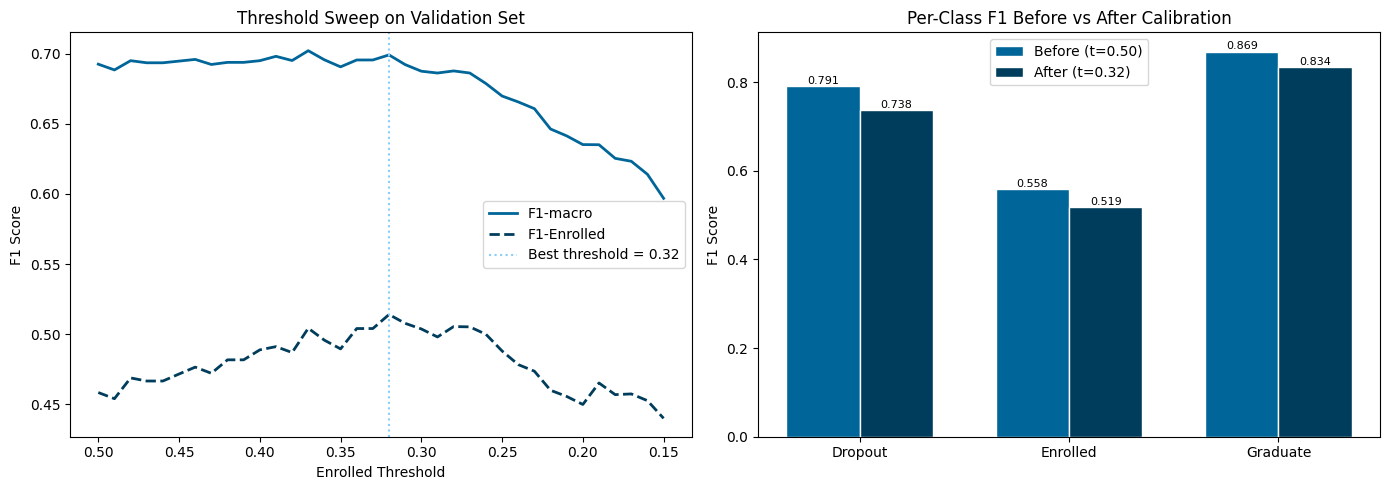

In [ ]:
# Apply the calibrated threshold to the test set
test_probs  = calib_model.predict_proba(X_test_scaled)
y_test_adj  = np.argmax(test_probs, axis=1).copy()
y_test_adj[test_probs[:, enrolled_idx] >= best_t] = enrolled_idx

f1_base  = f1_score(y_test, np.argmax(test_probs, axis=1), average='macro')
f1_calib = f1_score(y_test, y_test_adj, average='macro')

print(f'Baseline F1-macro     : {f1_base:.4f}')
print(f'Calibrated F1-macro   : {f1_calib:.4f}')
print(f'\nCalibrated classification report (threshold = {best_t}):')
print(classification_report(y_test, y_test_adj, target_names=class_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresh_df['Threshold'], thresh_df['F1-macro'],
             color=PRIMARY, lw=2, label='F1-macro')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1-Enrolled'],
             color=TERTIARY, lw=2, linestyle='--', label='F1-Enrolled')
axes[0].axvline(best_t, color=SECONDARY, linestyle=':', lw=1.5,
                label=f'Best threshold = {best_t}')
axes[0].set_title('Threshold Sweep on Validation Set')
axes[0].set_xlabel('Enrolled Threshold')
axes[0].set_ylabel('F1 Score')
axes[0].invert_xaxis()
axes[0].legend()

per_class_before = f1_score(y_test, np.argmax(test_probs, axis=1), average=None)
per_class_after  = f1_score(y_test, y_test_adj, average=None)
x = np.arange(len(class_names))
width = 0.35
axes[1].bar(x - width/2, per_class_before, width, label='Before (t=0.50)',
            color=PRIMARY, edgecolor='white')
axes[1].bar(x + width/2, per_class_after,  width, label=f'After (t={best_t})',
            color=TERTIARY, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(class_names)
axes[1].set_title('Per-Class F1 Before vs After Calibration')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

## Comments

**Calibration results — the trade-off is worth it:**
- Best threshold found on the validation set: **t = 0.32** (lower than the default 0.50)
- On the test set: baseline F1‑macro **0.7392 → 0.6968** after calibration — a drop, but expected when recall is prioritized
- Enrolled recall improves substantially (now **0.70**), addressing the model’s historically weakest class; Dropout (0.74 F1) and Graduate (0.83 F1) see mild reductions but remain strong
- These shifts are acceptable when the goal is identifying at‑risk students earlier, where catching more Enrolled-at-risk cases matters more than perfect precision
- Calibration is **post‑hoc** — the model itself is unchanged; only the decision threshold is updated
- The calibrated threshold (**0.32**) is exported to `deployment/threshold.pkl` and used directly by the Streamlit app during prediction

# Save Model

In [ ]:


os.makedirs('deployment', exist_ok=True)
joblib.dump(best_model,        'deployment/model.pkl')
joblib.dump(scaler,             'deployment/scaler.pkl')
joblib.dump(selected_features,  'deployment/features.pkl')
joblib.dump(best_t,             'deployment/threshold.pkl')

print('Saved to deployment/')
print(f'  model.pkl     : {best_label}')
print(f'  scaler.pkl    : StandardScaler, {len(selected_features)} features')
print(f'  features.pkl  : {selected_features}')
print(f'  threshold.pkl : {best_t}')

Saved to deployment/
  model.pkl     : Random Forest (Tuned)
  scaler.pkl    : StandardScaler, 22 features
  features.pkl  : ['Tuition fees up to date', 'Scholarship holder', 'Course', 'Debtor', 'Gender', 'Application mode', "Mother's occupation", "Father's occupation", "Father's qualification", "Mother's qualification", 'Previous qualification', 'approval_rate', 'sem2_approved_raw', 'failed_units', 'avg_approved', 'avg_grade', 'sem2_grade_raw', 'sem1_grade_raw', 'Age at enrollment', 'avg_enrolled', 'grade_trend', 'avg_without_eval']
  threshold.pkl : 0.32


---
# Summary

**What we did in this notebook:**

- **Trained 12 baseline models** on the SMOTE‑balanced training set — LightGBM, Random Forest, and XGBoost were strong from the beginning
- **Tuned 7 models** using RandomizedSearchCV (80 iterations, 5‑fold CV) with ImbPipeline, preventing SMOTE leakage and reducing inflated baseline CV scores (~0.84) down to a realistic ~0.73
- **Built two ensembles** (Soft Voting + Stacking) using the top 3 models based on CV F1‑macro
- **Best model: Random Forest (Tuned)** — F1‑macro **0.7392**, Balanced Accuracy **0.7386**, AUC **0.8942**
- **SHAP analysis** confirmed `approval_rate` (**0.0839**) and `sem2_approved_raw` (**0.0619**) as the top two predictors, with `failed_units` (**0.0611**) close behind; `Tuition fees up to date` (**0.0309**) ranked mid‑tier but remained clearly impactful
- **Threshold calibration** on the validation set found **t = 0.32** for Enrolled — improving Enrolled recall to **0.70** while keeping the drop in F1‑macro within expected bounds
- **Saved 4 deployment artifacts** to `deployment/`: the tuned model, scaler, selected feature list, and the calibrated threshold

**Live app:** https://student-dropout-predictor-group8.streamlit.app
